In [2]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, MessagesState
from langgraph.prebuilt import ToolNode
import os

c:\Users\Admin\Documents\ML_Projects\Agentic_AI\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
LANGCHAIN_API_KEY=os.getenv("LANGCHAIN_API_KEY")
LANGCHAIN_PROJECT=os.getenv("LANGCHAIN_PROJECT")

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-1.0-pro")

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0
)

In [6]:
@tool
def search(query:str):
    """Call to surf the web."""
    # This is a placeholder, but don't tell the LLM that...
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "It's 60 degrees and foggy."
    return "It's 90 degrees and sunny." 

In [7]:
tools = [search]


In [8]:
tool_node = ToolNode(tools)

In [9]:
model=llm

In [10]:
def should_continue(state: MessagesState) -> Literal["tools", END]:
    print(f"here is a state {state}")
    messages = state['messages']
    print(f"here is message {messages}")
    last_message = messages[-1]
    print(f"here is a last message {last_message}")
    # If the LLM makes a tool call, then we route to the "tools" node
    if last_message.tool_calls:
        return "tools"
    # Otherwise, we stop (reply to the user)
    return END

In [11]:
# Define the function that calls the model
def call_model(state: MessagesState):
    messages = state['messages']
    print(f"here is message from call model {messages}")
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [12]:
# Define a new graph
workflow = StateGraph(MessagesState)

In [13]:
# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

In [14]:
# Set the entrypoint as `agent`
# This means that this node is the first one called
workflow.add_edge(START, "agent")

In [15]:
# We now add a conditional edge
workflow.add_conditional_edges(
    # First, we define the start node. We use `agent`.
    # This means these are the edges taken after the `agent` node is called.
    "agent",
    # Next, we pass in the function that will determine which node is called next.
    should_continue,
)

In [16]:

# We now add a normal edge from `tools` to `agent`.
# This means that after `tools` is called, `agent` node is called next.
workflow.add_edge("tools", 'agent')

In [17]:
# Initialize memory to persist state between graph runs
checkpointer = MemorySaver()

In [18]:

# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable.
# Note that we're (optionally) passing the memory when compiling the graph
app = workflow.compile(checkpointer=checkpointer)

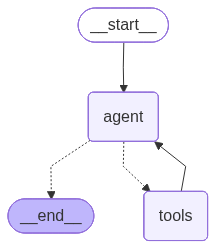

In [19]:
app

In [20]:
# Use the Runnable
final_state = app.invoke(
    {"messages": [HumanMessage(content="what is the weather in sf")]},
    config={"configurable": {"thread_id": 42}}
)


here is message from call model [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='4043aa4d-8e56-4775-84ff-6844828b272c')]
here is a state {'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='4043aa4d-8e56-4775-84ff-6844828b272c'), AIMessage(content='The weather in San Francisco can vary greatly throughout the year. In general, the city has a mild climate with cool, foggy summers and wet winters. The average temperature in the summer months is around 60-70°F (15-21°C), while in the winter months it is around 50-60°F (10-15°C). It is always a good idea to check a reliable weather forecast for the most up-to-date information.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 13, 'total_tokens': 103, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_predi

In [21]:
final_state["messages"][-1].content

'The weather in San Francisco can vary greatly throughout the year. In general, the city has a mild climate with cool, foggy summers and wet winters. The average temperature in the summer months is around 60-70°F (15-21°C), while in the winter months it is around 50-60°F (10-15°C). It is always a good idea to check a reliable weather forecast for the most up-to-date information.'

In [22]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="what about ny")]},
    config={"configurable": {"thread_id": 42}}
)
final_state["messages"][-1].content

here is message from call model [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='4043aa4d-8e56-4775-84ff-6844828b272c'), AIMessage(content='The weather in San Francisco can vary greatly throughout the year. In general, the city has a mild climate with cool, foggy summers and wet winters. The average temperature in the summer months is around 60-70°F (15-21°C), while in the winter months it is around 50-60°F (10-15°C). It is always a good idea to check a reliable weather forecast for the most up-to-date information.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 13, 'total_tokens': 103, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprin

'The weather in New York City also varies throughout the year. Summers in NYC are typically hot and humid, with temperatures ranging from 70-90°F (21-32°C). Winters can be cold and snowy, with temperatures ranging from 20-40°F (-6 to 4°C). Spring and fall are generally mild with temperatures in the 50-70°F (10-21°C) range. It is recommended to check a reliable weather forecast for the most accurate and up-to-date information on the weather in New York City.'

In [23]:

final_state = app.invoke(
    {"messages": [HumanMessage(content="what you know about the stock market?")]},
    config={"configurable": {"thread_id": 42}}
)
final_state["messages"][-1].content

here is message from call model [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='4043aa4d-8e56-4775-84ff-6844828b272c'), AIMessage(content='The weather in San Francisco can vary greatly throughout the year. In general, the city has a mild climate with cool, foggy summers and wet winters. The average temperature in the summer months is around 60-70°F (15-21°C), while in the winter months it is around 50-60°F (10-15°C). It is always a good idea to check a reliable weather forecast for the most up-to-date information.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 13, 'total_tokens': 103, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprin

'The stock market is a place where investors can buy and sell shares of publicly traded companies. It is a key component of the financial system and plays a crucial role in the economy. Stock prices are determined by supply and demand, as well as various economic factors, company performance, and market sentiment.\n\nInvesting in the stock market can be a way to potentially grow wealth over time, but it also comes with risks. Stock prices can be volatile and can fluctuate based on a variety of factors, including economic conditions, geopolitical events, and company news.\n\nThere are different types of stocks, such as common stocks, preferred stocks, and penny stocks, each with its own characteristics and risks. It is important for investors to do their research, diversify their investments, and consider their risk tolerance before investing in the stock market.'


The 2nd Chapter

In [24]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [25]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [26]:

# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

In [27]:
graph_builder.add_edge(START, "chatbot")

In [28]:
graph_builder.add_edge("chatbot", END)

In [29]:
graph = graph_builder.compile()

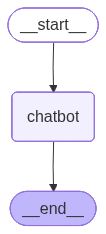

In [30]:
graph

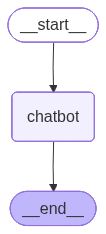

In [31]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
while True:
    user_input = input("User: ")
    print("User: "+ user_input)
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    for event in graph.stream({"messages": ("user", user_input)}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

User: what is machine leanring
Assistant: Machine learning is a subset of artificial intelligence that involves the development of algorithms and statistical models that enable computers to learn from and make predictions or decisions based on data without being explicitly programmed. It allows computers to analyze and interpret complex data, identify patterns, and make decisions or predictions without human intervention. Machine learning algorithms can be used in a wide range of applications, such as image and speech recognition, natural language processing, recommendation systems, and predictive analytics.
User: explain in brief and its types
Assistant: Explain in brief:

Explanation is the act of making something clear or understandable by providing information or details. It involves breaking down complex concepts or ideas into simpler terms so that others can easily grasp the meaning.

Types of explanation:

1. Scientific explanation: This type of explanation is based on empirical


Enhancing Chatbot with tools

In [32]:

from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]
tool.invoke("What's a 'node' in LangGraph?")

C:\Users\Admin\AppData\Local\Temp\ipykernel_8952\2584952444.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2)


[{'title': "A Beginner's Guide to Getting Started with Nodes in LangGraph",
  'url': 'https://medium.com/ai-engineering-bootcamp/a-beginners-guide-to-getting-started-with-nodes-in-langgraph-cdd551e8d79c',
  'content': 'This logic is the “why” of the node — its purpose.\n\nIf you read my earlier pieces on reducers and state updates, you’ll notice that node logic often results in new data being produced, which your reducers then merge into the global state.\n\n## 3. Output: What the Node Produces\n\nAfter the logic runs, the node spits out something new — usually part of the state. LangGraph takes this result, merges it into the state (thanks to reducers), and carries the updated backpack forward to the next node.\n\n## 4. Edges: The Next Step\n\nThis is the part beginners often overlook.\n\nA node doesn’t live alone in the void — it needs edges to tell LangGraph:\n\n   _Where to go next?_\n   _Which node should follow this one?_\n   _Is this a normal transition or a conditional one?_\n 

In [36]:
from typing import Annotated 
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder  = StateGraph(State)

# Modification: tell the LLM which tools it can call
llm_with_tools = llm.bind_tools(tools)

def chatbot(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

In [37]:

import json

from langchain_core.messages import ToolMessage


class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}


tool_node = BasicToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

In [38]:

from typing import Literal


def route_tools(
    state: State,
) -> Literal["tools", "__end__"]:
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"


# The `tools_condition` function returns "tools" if the chatbot asks to use a tool, and "__end__" if
# it is fine directly responding. This conditional routing defines the main agent loop.
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node
    # It defaults to the identity function, but if you
    # want to use a node named something else apart from "tools",
    # You can update the value of the dictionary to something else
    # e.g., "tools": "my_tools"
    {"tools": "tools", "__end__": "__end__"},
)

In [39]:
# Any time a tool is called, we return to the chatbot to decide the next step

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

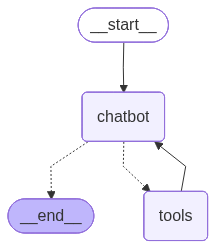

In [40]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:

from langchain_core.messages import BaseMessage

while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            if isinstance(value["messages"][-1], BaseMessage):
                print("Assistant:", value["messages"][-1].content)

Assistant: Hello! How can I assist you today?
Assistant: Hello! How can I assist you today?
Assistant: Hello! How can I assist you today?
Assistant: Hello! How can I assist you today?
Assistant: Hello! How can I assist you today?
Assistant: Hello! How can I assist you today?
Assistant: Hello! How can I assist you today?
Assistant: Hello! How can I assist you today?
Assistant: Hello! How can I assist you today?


In [ ]:
config = {"configurable": {"thread_id": "1"}}

In [ ]:

user_input = "Hi there! My name is Will."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Will.
================================== Ai Message ==================================

Hello Will! How can I assist you today?


In [ ]:
user_input = "Remember my name?"

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Remember my name?
================================== Ai Message ==================================

Of course, I remember your name! How can I assist you today?


In [ ]:
# The only difference is we change the `thread_id` here to "2" instead of "1"
events = graph.stream(
    {"messages": [("user", user_input)]},
    {"configurable": {"thread_id": "2"}},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Remember my name?
================================== Ai Message ==================================

Of course, I remember your name! How can I assist you today?


In [45]:

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START, END

model = ChatOpenAI(model="gpt-4o-mini")


def call_model(state: MessagesState):
    response = model.invoke(state['messages'])
    return {"messages": response}

workflow = StateGraph(MessagesState)
workflow.add_node(call_model)
workflow.add_edge(START, "call_model")
workflow.add_edge("call_model", END)
app = workflow.compile()

inputs = [{"role": "user", "content": "hi!"}]
async for event in app.astream_events({"messages": inputs}, version="v1"):
    kind = event["event"]
    print(f"{kind}: {event['name']}")

on_chain_start: LangGraph
on_chain_start: call_model
on_chain_stream: call_model
on_chain_end: call_model
on_chain_stream: LangGraph
on_chain_end: LangGraph
